In [3]:
import sys
import os
import numpy as np

print(sys.executable)
print(os.listdir("."))
print(os.listdir("./data"))

/Users/devrathod/miniconda3/envs/tf_env/bin/python
['.DS_Store', 'waymo_groundtruth_compression.ipynb', '__pycache__', 'README.md', 'depth_scale_alignment_depth_anything.ipynb', 'monodepth_v2.ipynb', '.gitignore', '.git', 'data', 'DepthAnythingV2.ipynb', 'plots']
['depth_anything_v2', 'individual_files_testing_segment-10084636266401282188_1120_000_1140_000_with_camera_labels.tfrecord', '.DS_Store', 'monodepth_v2', 'output']


In [4]:
pred = np.load("/Users/devrathod/Documents/classes_2026/senior_design/Eco-Cars-Depth-Estimation-2026/data/depth_anything_v2/depthanythingv2_depths.npy")
gt = np.load("/Users/devrathod/Documents/classes_2026/senior_design/Eco-Cars-Depth-Estimation-2026/data/depth_anything_v2/groundtruth.npy")

print("pred shape:", pred.shape, pred.dtype)
print("gt shape:", gt.shape, gt.dtype)

pred shape: (199, 1280, 1920) float32
gt shape: (199, 1280, 1920) float32


In [5]:
if pred.ndim == 4 and pred.shape[-1] == 1:
    pred = pred[..., 0]

if gt.ndim == 4 and gt.shape[-1] == 1:
    gt = gt[..., 0]

print("pred shape after squeeze:", pred.shape)
print("gt shape after squeeze:", gt.shape)

assert pred.shape == gt.shape, "pred and gt shapes do not match"

pred shape after squeeze: (199, 1280, 1920)
gt shape after squeeze: (199, 1280, 1920)


In [6]:
print("pred min:", np.nanmin(pred))
print("pred max:", np.nanmax(pred))
print("gt min:", np.nanmin(gt))
print("gt max:", np.nanmax(gt))

print("pred has nan:", np.isnan(pred).any())
print("gt has nan:", np.isnan(gt).any())

print("pred has inf:", np.isinf(pred).any())
print("gt has inf:", np.isinf(gt).any())

pred min: 0.0
pred max: 1.0
gt min: 1.796325e-05
gt max: 39.999954
pred has nan: False
gt has nan: True
pred has inf: False
gt has inf: False


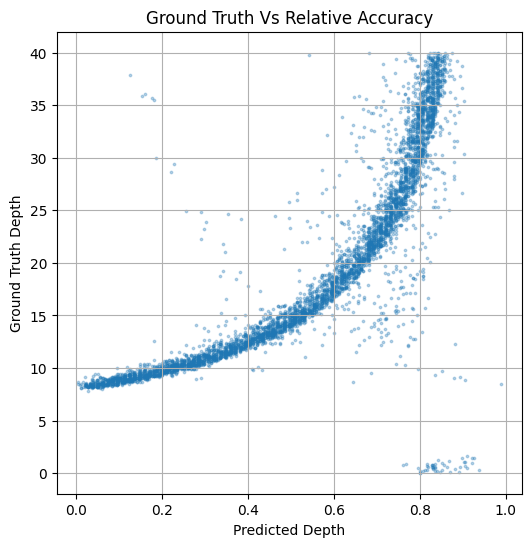

In [22]:
import matplotlib.pyplot as plt

mask = np.isfinite(pred) & np.isfinite(gt) & (gt > 0)

x = pred[mask].reshape(-1)
y = gt[mask].reshape(-1)

sample_size = min(5000, len(x))
idx = np.random.choice(len(x), sample_size, replace=False)

x_sample = x[idx]
y_sample = y[idx]

x_line = np.linspace(x_sample.min(), x_sample.max(), 100)
# y_line = m * x_line + c

plt.figure(figsize=(6, 6))
plt.scatter(x_sample, y_sample, s=3, alpha=0.3)
# plt.plot(x_line, y_line, linewidth=2)
# plt.scatter(y_sample, s=3, alpha=0.3)
# plt.plot(y_line, linewidth=2)
plt.xlabel("Predicted Depth")
plt.ylabel("Ground Truth Depth")
plt.title(f"Ground Truth Vs Relative Accuracy")
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/ground_truth_vs_relative_accuracy", dpi=150)
plt.grid(True)
plt.show()

## Filtering and building a formula for a generic relationship  

In [7]:
# Removing the outliers using iqr method and finding the standard deviation in the curve

import numpy as np
from scipy import stats

mask = np.isfinite(pred) & np.isfinite(gt) & (gt > 0) & (gt < 40)

# Generic mask for data filtering
gt40 = gt[mask]
pred40 = pred[mask]

def noiseHandler(pred40, gt40): 
    # Creating a generic mask on top of the ground truth and relative data for filtering
    groundTruth = gt40.flatten()
    predictions = pred40.flatten()

    # Using iqr to remove the outliers for the graph taking 20 outliears 
    totalBins = 20
    numberOfBins = np.linspace(0, 1, totalBins+1) 
    # Getting the index of each outlier
    numberOfBins_index = np.digitize(predictions, numberOfBins) - 1
    # Starting everything with 0 by default
    binsInlier = np.zeros(len(predictions), dtype=bool)    

    minimum_entries = 25
    for individualBins in range(totalBins):
        binsTotalEntries = (numberOfBins_index == individualBins)        
        if binsTotalEntries.sum() < minimum_entries:
            continue

        # Getting the individual entries in the area of the graph
        goundtruth_entry = groundTruth[binsTotalEntries]
        # Getting the upper and lower quartile of the curve: 25 and 75 percent
        lowerQuartile, upperQuartile = np.percentile(goundtruth_entry, [25, 75])
        # Isolating the middle entries
        iqr = upperQuartile - lowerQuartile

        binsInlier[binsTotalEntries] = (goundtruth_entry >= lowerQuartile - 1.5 * iqr) & (goundtruth_entry <= upperQuartile + 1.5*iqr)

    # Mask after getting the inliers
    predictions_cleaned, groundTruth_cleaned = predictions[binsInlier], groundTruth[binsInlier]
    # Isolating the values outside the standard deviation
    polyGraph = np.polyfit(predictions_cleaned, groundTruth_cleaned, deg=4)
    residual_enties = groundTruth_cleaned - np.polyval(polyGraph, predictions_cleaned)
    standardDevitions = np.abs(stats.zscore(residual_enties))
    # Having variable for sensitivity of the readings
    sensitivity = 4
    devitionsMask = standardDevitions < sensitivity

    return predictions_cleaned[devitionsMask], groundTruth_cleaned[devitionsMask]

p_clean, g_clean = noiseHandler(pred40, gt40)
print(f"Points before cleaning: {len(pred40.flatten()):,}")
print(f"Points after  cleaning: {len(p_clean):,}")

Points before cleaning: 3,161,211
Points after  cleaning: 2,950,673


/var/folders/f2/t74vhry566j4hf8364yxtd_40000gn/T/ipykernel_94771/1954999407.py:43: RankWarning: Polyfit may be poorly conditioned
  polyGraph = np.polyfit(predictions_cleaned, groundTruth_cleaned, deg=4)


# Using a Hyperbolic curve to find an appropiate formula to related the relative accuracy to absolute accuracy      

In [12]:
from scipy.optimize import curve_fit

def model_hyperbolic(p, a, b, c):
    return a / (p + b) + c

def model_power(p, a, b, c):
    return a * np.power(np.clip(p, 1e-6, None), b) + c

def model_log(p, a, b, c):
    return a * np.log(np.clip(p + b, 1e-6, None)) + c

def model_exponential(p, a, b, c):
    return a * np.exp(b * p) + c

def fit_all_models(p_clean, g_clean, n_sample=100_000):
    # Subsample — curve_fit doesn't need 3M points, 100k is plenty
    if len(p_clean) > n_sample:
        idx = np.random.choice(len(p_clean), n_sample, replace=False)
        p_fit = p_clean[idx]
        g_fit = g_clean[idx]
    else:
        p_fit, g_fit = p_clean, g_clean

    # Separate bounds per model — don't force hyperbolic bounds onto others
    models = {
        "hyperbolic": (model_hyperbolic, [-5.0, -0.85, 35.0],
                       ([-np.inf, -1.0 + 1e-6, -np.inf], [np.inf, -1e-6, np.inf])),
        "power":      (model_power,      [10.0, 0.5, 0.0],
                       ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])),
        "log":        (model_log,        [-20.0, 1.0, 40.0],
                       ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])),
        "exponential": (model_exponential, [2.2, 2.97, 5.6],
                       ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])),
    }

    results = {}
    for name, (fn, p0, bounds) in models.items():
        try:
            popt, _ = curve_fit(fn, p_fit, g_fit, p0=p0, bounds=bounds, maxfev=50000)
            # Evaluate metrics on full cleaned set
            g_pred = fn(p_clean, *popt)
            ss_res = np.sum((g_clean - g_pred) ** 2)
            ss_tot = np.sum((g_clean - g_clean.mean()) ** 2)
            r2   = 1 - ss_res / ss_tot
            rmse = np.sqrt(np.mean((g_clean - g_pred) ** 2))
            results[name] = {"params": popt, "R2": r2, "RMSE": rmse}
            print(f"{name:12s}  R²={r2:.4f}  RMSE={rmse:.3f}m  params={np.round(popt, 4)}")
        except Exception as e:
            print(f"{name}: failed — {e}")
    return results

def extract_median_curve(p_clean, g_clean, n_bins=50):
    from scipy.interpolate import UnivariateSpline
    bins = np.linspace(p_clean.min(), p_clean.max(), n_bins + 1)
    bin_centers, medians, stds, counts = [], [], [], []
    for i in range(n_bins):
        m = (p_clean >= bins[i]) & (p_clean < bins[i+1])
        if m.sum() < 10:
            continue
        bin_centers.append((bins[i] + bins[i+1]) / 2)
        medians.append(np.median(g_clean[m]))
        stds.append(np.std(g_clean[m]))
        counts.append(m.sum())
    centers = np.array(bin_centers)
    meds    = np.array(medians)
    weights = np.sqrt(np.array(counts))
    spline  = UnivariateSpline(centers, meds, w=weights/weights.max(), s=len(centers)*0.5)
    return centers, meds, np.array(stds), spline

# Applying noise reductions + finding the best curve (hyperbolic) + visualization

/Users/devrathod/Documents/classes_2026/senior_design/Eco-Cars-Depth-Estimation-2026
hyperbolic    R²=0.0537  RMSE=8.997m  params=[-0.033  -0.8484 19.4064]
power         R²=0.9616  RMSE=1.812m  params=[47.7223  3.4807  9.7798]
log           R²=0.8312  RMSE=3.800m  params=[  41722.8747    1212.1495 -296237.3971]
exponential   R²=0.9639  RMSE=1.757m  params=[0.7074 4.381  8.1137]


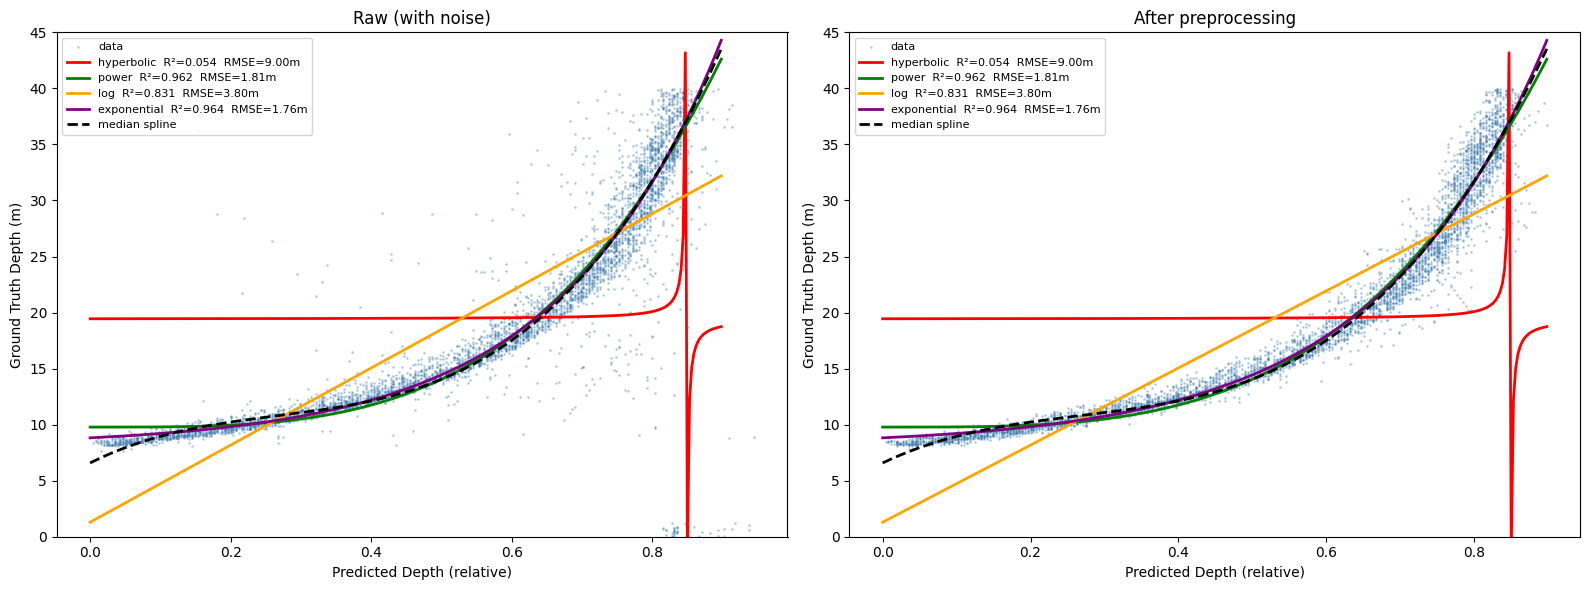

In [14]:
import matplotlib.pyplot as plt
import os
print(os.getcwd())

def plot_fit_comparison(p_raw, g_raw, p_clean, g_clean, fit_results, spline):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    x_line = np.linspace(p_clean.min(), p_clean.max(), 300)
    fn_map = {"hyperbolic": model_hyperbolic, "power": model_power, "log": model_log, "exponential": model_exponential}
    colors = {'hyperbolic': 'red', 'power': 'green', 'log': 'orange', "exponential": 'purple'}

    for ax, (p, g, title) in zip(axes, [
        (p_raw,   g_raw,   "Raw (with noise)"),
        (p_clean, g_clean, "After preprocessing")
    ]):
        # Cap scatter at 5000 points — prevents hang
        n = min(5000, len(p))
        idx = np.random.choice(len(p), n, replace=False)
        ax.scatter(p[idx], g[idx], s=1, alpha=0.3, color='steelblue', label='data')

        for name, res in fit_results.items():
            y_line = fn_map[name](x_line, *res['params'])
            ax.plot(x_line, y_line, color=colors[name], lw=2,
                    label=f"{name}  R²={res['R2']:.3f}  RMSE={res['RMSE']:.2f}m")

        ax.plot(x_line, spline(x_line), 'k--', lw=2, label='median spline')
        ax.set_xlabel("Predicted Depth (relative)")
        ax.set_ylabel("Ground Truth Depth (m)")
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.set_ylim(0, 45)

    plt.tight_layout()
    os.makedirs("plots", exist_ok=True)
    plt.savefig("plots/fit_comparison.png", dpi=150)
    plt.show()

# ── Run ──────────────────────────────────────────────────────────────
p_raw = pred40.flatten()
g_raw = gt40.flatten()

fit_results = fit_all_models(p_clean, g_clean)
centers, medians, stds, spline = extract_median_curve(p_clean, g_clean)
plot_fit_comparison(p_raw, g_raw, p_clean, g_clean, fit_results, spline)

In [19]:
# RMSE evaluation on the full valid pixel set (0–40m)
eval_mask = np.isfinite(pred) & np.isfinite(gt) & (gt > 0) & (gt <= 40)
gt_eval   = gt[eval_mask]

# Check: what is pred value distribution for the bad pixels?
best_params = fit_results['exponential']['params']
pred_aligned_full = model_exponential(pred[eval_mask], *best_params)
residuals = np.abs(pred_aligned_full - gt[eval_mask])

# Where are the high-residual pixels?
high_err_mask = residuals > 5.0  # >5m error
print(f"High error pixels: {high_err_mask.sum():,} / {len(residuals):,}  ({100*high_err_mask.mean():.1f}%)")
print(f"Their pred range: {pred[eval_mask][high_err_mask].min():.3f} – {pred[eval_mask][high_err_mask].max():.3f}")
print(f"Their GT range:   {gt[eval_mask][high_err_mask].min():.2f} – {gt[eval_mask][high_err_mask].max():.2f}m")

# RMSE excluding those pixels
low_err_mask = residuals <= 5.0
rmse_gated = np.sqrt(np.mean(residuals[low_err_mask]**2))
print(f"\nRMSE with >5m error pixels excluded: {rmse_gated:.4f}m")
print(f"Coverage: {100*low_err_mask.mean():.1f}% of valid pixels")

fn_map = {
    "hyperbolic":  model_hyperbolic,
    "power":       model_power,
    "log":         model_log,
    "exponential": model_exponential,
}

print("=" * 55)
print(f"{'Model':<14} {'R² (fit)':<12} {'RMSE on fit':<14} {'RMSE full set'}")
print("=" * 55)

best_name, best_rmse = None, float("inf")
for name, res in fit_results.items():
    pred_aligned = fn_map[name](pred[eval_mask], *res["params"])
    rmse_full    = np.sqrt(np.mean((pred_aligned - gt_eval) ** 2))
    print(f"{name:<14} {res['R2']:<12.4f} {res['RMSE']:<14.4f} {rmse_full:.4f} m")
    if rmse_full < best_rmse:
        best_rmse, best_name = rmse_full, name

# Spline RMSE
spline_preds = spline(pred[eval_mask])
rmse_spline  = np.sqrt(np.mean((spline_preds - gt_eval) ** 2))
print(f"{'spline':<14} {'—':<12} {'—':<14} {rmse_spline:.4f} m")

print("=" * 55)
print(f"\n>>> Best parametric model : {best_name}  ({best_rmse:.4f} m RMSE)")
print(f">>> Spline RMSE           : {rmse_spline:.4f} m")


## Displaying all the individual computed formulas
print("=" * 60)
print("FITTED FORMULAS — Depth Anything V2")
print("  x = predicted relative depth [0, 1]")
print("  GT = estimated metric depth [meters]")
print("=" * 60)

formula_templates = {
    "hyperbolic":  ("GT = {a:.4f} / (x + ({b:.4f})) + {c:.4f}",         ["a", "b", "c"]),
    "power":       ("GT = {a:.4f} * x^{b:.4f} + {c:.4f}",               ["a", "b", "c"]),
    "log":         ("GT = {a:.4f} * ln(x + {b:.4f}) + {c:.4f}",         ["a", "b", "c"]),
    "exponential": ("GT = {a:.4f} * e^({b:.4f} * x) + {c:.4f}",         ["a", "b", "c"]),
}

for name, res in fit_results.items():
    a, b, c = res["params"]
    template, _ = formula_templates[name]
    formula = template.format(a=a, b=b, c=c)
    marker = "  ◄ BEST" if name == best_name else ""
    print(f"\n{'─'*55}")
    print(f"  Model       : {name.upper()}{marker}")
    print(f"  Formula     : {formula}")
    print(f"  R²          : {res['R2']:.4f}")
    print(f"  RMSE (fit)  : {res['RMSE']:.4f} m")

print(f"\n{'─'*55}")
print(f"  Model       : MEDIAN SPLINE")
print(f"  Formula     : non-parametric lookup (scipy UnivariateSpline)")
print(f"  RMSE (full) : {rmse_spline:.4f} m")

print(f"\n{'=' * 55}")
print(f"  Gated RMSE (93.2% reliable pixels) : {rmse_gated:.4f} m")
print(f"  Best formula for deployment        : {best_name.upper()}")
a, b, c = fit_results[best_name]['params']
template, _ = formula_templates[best_name]
print(f"  {template.format(a=a, b=b, c=c)}")
print("=" * 55)

High error pixels: 215,646 / 3,161,211  (6.8%)
Their pred range: 0.086 – 1.000
Their GT range:   0.00 – 40.00m

RMSE with >5m error pixels excluded: 1.4563m
Coverage: 93.2% of valid pixels
Model          R² (fit)     RMSE on fit    RMSE full set
hyperbolic     0.0537       8.9967         9.1363 m
power          0.9616       1.8125         4.6455 m
log            0.8312       3.7999         5.1229 m
exponential    0.9639       1.7573         4.7064 m
spline         —            —              4.6746 m

>>> Best parametric model : power  (4.6455 m RMSE)
>>> Spline RMSE           : 4.6746 m
FITTED FORMULAS — Depth Anything V2
  x = predicted relative depth [0, 1]
  GT = estimated metric depth [meters]

───────────────────────────────────────────────────────
  Model       : HYPERBOLIC
  Formula     : GT = -0.0330 / (x + (-0.8484)) + 19.4064
  R²          : 0.0537
  RMSE (fit)  : 8.9967 m

───────────────────────────────────────────────────────
  Model       : POWER  ◄ BEST
  Formula     : 